# SNAr safety-constrained multi-agent case study

The paper's safety-constrained optimisation experiment: compares **GP-BO**,
**SingleAgent**, **SafeAgent** (single RAG-grounded safety agent), and
**SafePCV** (`multiagent_specialists` -- an iterative safety-gated recheck
loop with a dedicated Safety Fallback Agent) on a mechanistic SNAr kinetic
ODE simulator (Hone et al. 2017) with a calibrated thermal-runaway hazard
proxy. 20 seeds x 15 iterations, `qwen2.5:7b`.

Writes `checkpoint_safety_multiagent_snar.pkl`, which feeds Figures 9-11 and
15 and Tables 2-3 via `scripts/generate_figures.py`.

This is `v2` of the safety experiment: it replaces `v1`'s single-shot
Arbiter (one LLM call merging two independent verdicts) with an iterative
safety-gated recheck loop, and scales from 7 to 20 seeds. `v1`
(`dia15_safety_multiagent.ipynb`) explicitly deleted its own checkpoint
right after writing it in its own code -- a discarded pilot run -- and has
been removed from this repository; this notebook (`v2`) is the confirmed
source of the shipped checkpoint (see `experiments/README.md` for the
file-timestamp/row-count evidence).

**Scope note:** this notebook's SNAr simulator and safety-agent code is
**not** factored into the shared `bayesllm` package, for the same reason
given in `snar_rag_grounding.ipynb`: a programmatic diff against that
notebook's superficially similar simulator functions showed real,
non-trivial differences, so each is kept as a direct, unmodified extraction
of its own original notebook rather than risk silently unifying them.

Renamed from `dia15_safety_multiagent_v2.ipynb`.


In [1]:
import numpy as np
import pandas as pd
import torch
import json
import ollama
import re
import pickle
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import LogExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood

from sentence_transformers import SentenceTransformer

C:\Users\<user>\OneDrive\Documentos\bayesllm-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# Cell 2: SNAr kinetic simulator (reused from dia14, verified)
# ============================================================

R_GAS_CONSTANT_SNAR = 8.314e-3            # kJ/(K·mol)
T_REF_OFFSET_SNAR = 273.71
T_REF_KELVIN_SNAR = 90.0 + T_REF_OFFSET_SNAR
REACTOR_VOLUME_ML_SNAR = 5.0              # mL
ETHANOL_DENSITY_SNAR = 0.789              # g/mL
MOLAR_MASSES_SNAR = np.array([159.09, 71.12, 210.21, 210.21, 261.33])
ARRHENIUS_PARAMS_SNAR = {
    "k_a": (57.9, 33.3), "k_b": (2.70, 35.3),
    "k_c": (0.865, 38.9), "k_d": (1.63, 44.8),
}
ARRHENIUS_PREFACTOR_SNAR = 0.6

def compute_rate_constants_snar(temperature_celsius):
    T_kelvin = temperature_celsius + T_REF_OFFSET_SNAR
    return {
        name: ARRHENIUS_PREFACTOR_SNAR * k_ref * np.exp(
            -(E_a / R_GAS_CONSTANT_SNAR) * (1.0 / T_kelvin - 1.0 / T_REF_KELVIN_SNAR)
        )
        for name, (k_ref, E_a) in ARRHENIUS_PARAMS_SNAR.items()
    }

def snar_ode_rhs(t, C, k_a, k_b, k_c, k_d, C_initial):
    C = np.array(C, dtype=float)
    for i in (0, 1):
        if C[i] < 1e-6 * C_initial[i]:
            C[i] = 0.0
    C0, C1, C2, C3, C4 = C
    return [
        -(k_a + k_b) * C0 * C1,
        -(k_a + k_b) * C0 * C1 - k_c * C1 * C2 - k_d * C1 * C3,
        k_a * C0 * C1 - k_c * C1 * C2,
        k_b * C0 * C1 - k_d * C1 * C3,
        k_c * C1 * C2 + k_d * C1 * C3,
    ]

def compute_sty_and_efactor_snar(C_final, q_tot):
    sty = 6e4 / 1000 * MOLAR_MASSES_SNAR[2] * C_final[2] * q_tot / REACTOR_VOLUME_ML_SNAR
    sty = max(sty, 1e-6)
    if np.isclose(C_final[2], 0.0):
        e_factor = 1e3
    else:
        mass_unreacted = 1e-3 * sum(
            MOLAR_MASSES_SNAR[i] * C_final[i] * q_tot for i in range(5) if i != 2
        )
        e_factor = (q_tot * ETHANOL_DENSITY_SNAR + mass_unreacted) / (
            1e-3 * MOLAR_MASSES_SNAR[2] * C_final[2] * q_tot
        )
    e_factor = min(e_factor, 1e3)
    return sty, e_factor

def run_virtual_experiment_snar(temperature_celsius, tau_min, equiv_pldn, conc_dfnb_M, noise_level_pct, rng):
    k = compute_rate_constants_snar(temperature_celsius)
    C_initial = np.array([conc_dfnb_M, equiv_pldn * conc_dfnb_M, 0.0, 0.0, 0.0])
    solution = solve_ivp(
        snar_ode_rhs, t_span=(0, tau_min), y0=C_initial,
        args=(k["k_a"], k["k_b"], k["k_c"], k["k_d"], C_initial),
        method="RK45", rtol=1e-8, atol=1e-10,
    )
    C_final_true = solution.y[:, -1]
    q_tot = REACTOR_VOLUME_ML_SNAR / tau_min
    true_sty, true_e_factor = compute_sty_and_efactor_snar(C_final_true, q_tot)
    C_final_noisy = C_final_true + (C_final_true * rng.normal(scale=noise_level_pct, size=5) / 100)
    C_final_noisy[C_final_noisy < 0] = 0.0
    observed_sty, observed_e_factor = compute_sty_and_efactor_snar(C_final_noisy, q_tot)
    return {
        "observed_sty": observed_sty, "observed_e_factor": observed_e_factor,
        "true_sty": true_sty, "true_e_factor": true_e_factor,
    }

# Search space: 4 continuous physical dimensions
BOUNDS_SNAR = torch.tensor([
    [0.5, 1.0, 0.1, 30.0],    # lower: tau, equiv_pldn, conc_dfnb, temperature
    [2.0, 5.0, 0.5, 120.0],   # upper
], dtype=torch.float64)
NOMBRES_DIMENSIONES_SNAR = ["tau", "equiv_pldn", "conc_dfnb", "temperature"]
N_DIMS_SNAR = BOUNDS_SNAR.shape[1]        # 4
N_INIT_SNAR = 2 * N_DIMS_SNAR             # 8

# Quick sanity check
rng_test = np.random.default_rng(0)
resultado_test = run_virtual_experiment_snar(
    temperature_celsius=90.0, tau_min=1.0, equiv_pldn=2.0, conc_dfnb_M=0.3,
    noise_level_pct=2.0, rng=rng_test,
)
print("Prueba simulador SNAr:", resultado_test)

Prueba simulador SNAr: {'observed_sty': np.float64(3181.4210710968737), 'observed_e_factor': np.float64(15.466186627937393), 'true_sty': np.float64(3141.187320905017), 'true_e_factor': np.float64(15.667304558990546)}


In [3]:
# ============================================================
# Cell 3: physical <-> tensor converters, and initial-point generator
# ============================================================

def tensor_a_dict_snar(x_tensor):
    """Convierte un tensor (1x4) en un diccionario con nombres físicos."""
    x_flat = x_tensor.flatten()
    return {
        "tau": x_flat[0].item(),
        "equiv_pldn": x_flat[1].item(),
        "conc_dfnb": x_flat[2].item(),
        "temperature": x_flat[3].item(),
    }

def dict_a_tensor_snar(d):
    """Convierte un diccionario físico en un tensor (1x4), en el orden de NOMBRES_DIMENSIONES_SNAR."""
    return torch.tensor(
        [[d["tau"], d["equiv_pldn"], d["conc_dfnb"], d["temperature"]]],
        dtype=torch.float64,
    )

def generar_puntos_iniciales_snar(n_puntos, seed):
    """Genera n_puntos aleatorios (uniformes) dentro de BOUNDS_SNAR, en unidades físicas."""
    rng = np.random.default_rng(seed)
    lower = BOUNDS_SNAR[0].numpy()
    upper = BOUNDS_SNAR[1].numpy()
    puntos = lower + rng.random((n_puntos, N_DIMS_SNAR)) * (upper - lower)
    return torch.tensor(puntos, dtype=torch.float64)

def objetivo_snar(d, noise_level_pct, rng):
    """Evalúa el simulador dado un diccionario físico. Devuelve el STY observado (variable a maximizar)."""
    resultado = run_virtual_experiment_snar(
        temperature_celsius=d["temperature"],
        tau_min=d["tau"],
        equiv_pldn=d["equiv_pldn"],
        conc_dfnb_M=d["conc_dfnb"],
        noise_level_pct=noise_level_pct,
        rng=rng,
    )
    return resultado["observed_sty"]

# Sanity check
puntos_test = generar_puntos_iniciales_snar(N_INIT_SNAR, seed=0)
print("Puntos iniciales (forma):", puntos_test.shape)
print("Ejemplo punto 0 como dict:", tensor_a_dict_snar(puntos_test[0]))

rng_obj_test = np.random.default_rng(0)
sty_test = objetivo_snar(tensor_a_dict_snar(puntos_test[0]), noise_level_pct=2.0, rng=rng_obj_test)
print("STY del punto 0:", sty_test)

Puntos iniciales (forma): torch.Size([8, 4])
Ejemplo punto 0 como dict: {'tau': 1.4554425309821815, 'equiv_pldn': 2.0791468550554812, 'conc_dfnb': 0.11638940957447788, 'temperature': 31.487487197567617}
STY del punto 0: 684.0771290644418


In [4]:
# ============================================================
# Cell 4: safety rule -- thermal runaway risk
# ============================================================

def compute_heat_release_proxy_snar(d):
    """
    Proxy de tasa de generación de calor en el instante inicial (t=0):
    proporcional a la tasa de reacción inicial (k_a + k_b) * C_DFNB_0 * C_PLDN_0.
    Como la SNAr es exotérmica, una tasa de reacción inicial alta implica
    una tasa de liberación de calor alta -> mayor riesgo de que el sistema
    de refrigeración del reactor no pueda disipar el calor a tiempo.
    """
    k = compute_rate_constants_snar(d["temperature"])
    C_dfnb_0 = d["conc_dfnb"]
    C_pldn_0 = d["equiv_pldn"] * d["conc_dfnb"]
    return (k["k_a"] + k["k_b"]) * C_dfnb_0 * C_pldn_0

# --- Threshold calibration via Monte Carlo sampling over the real space ---
rng_calib = np.random.default_rng(42)
N_CALIB = 5000
puntos_calib = generar_puntos_iniciales_snar(N_CALIB, seed=42)
proxies_calib = np.array([
    compute_heat_release_proxy_snar(tensor_a_dict_snar(puntos_calib[i]))
    for i in range(N_CALIB)
])

print("Percentiles del proxy de riesgo térmico:")
for p in [50, 70, 75, 80, 90, 95]:
    print(f"  P{p}: {np.percentile(proxies_calib, p):.3f}")

# Threshold: we fix the most extreme 20% of combinations (simultaneously high temp+conc) as "unsafe"
UMBRAL_RIESGO_SNAR = float(np.percentile(proxies_calib, 80))
print(f"\nUmbral de riesgo elegido (P80): {UMBRAL_RIESGO_SNAR:.3f}")

def es_inseguro_snar(d):
    """True si la combinación de condiciones supera el umbral de riesgo térmico."""
    return compute_heat_release_proxy_snar(d) > UMBRAL_RIESGO_SNAR

# Verification: fraction of unsafe points, and that the unsafe zone makes physical sense
fraccion_insegura = np.mean(proxies_calib > UMBRAL_RIESGO_SNAR)
print(f"Fracción de puntos en zona insegura: {fraccion_insegura:.3f}")

# Physical sanity check: unsafe points should skew toward high temp/conc
temps_calib = puntos_calib[:, 3].numpy()
concs_calib = puntos_calib[:, 2].numpy()
mask_inseguro = proxies_calib > UMBRAL_RIESGO_SNAR
print(f"Temp media (inseguros): {temps_calib[mask_inseguro].mean():.1f} vs (seguros): {temps_calib[~mask_inseguro].mean():.1f}")
print(f"Conc media (inseguros): {concs_calib[mask_inseguro].mean():.3f} vs (seguros): {concs_calib[~mask_inseguro].mean():.3f}")

Percentiles del proxy de riesgo térmico:
  P50: 4.630
  P70: 9.499
  P75: 11.516
  P80: 14.030
  P90: 24.280
  P95: 35.810

Umbral de riesgo elegido (P80): 14.030
Fracción de puntos en zona insegura: 0.200
Temp media (inseguros): 100.7 vs (seguros): 68.5
Conc media (inseguros): 0.405 vs (seguros): 0.275


In [5]:
# ============================================================
# Cell 5: Grounding corpus (general chemical safety) + leakage check
# ============================================================

safety_general_corpus_snar = {
    "exothermicity": (
        "Nucleophilic aromatic substitution (SNAr) reactions on nitroaromatic "
        "substrates are typically exothermic: formation of the Meisenheimer "
        "complex and subsequent departure of the leaving group release energy. "
        "The heat release rate of an exothermic reaction is proportional to its "
        "reaction rate."
    ),
    "arrhenius_qualitative": (
        "The rate of a chemical reaction increases non-linearly (exponentially) "
        "with temperature, following Arrhenius behavior. Small increases in "
        "temperature can produce disproportionate increases in reaction rate "
        "and, therefore, in the rate of heat generation."
    ),
    "concentration_effect": (
        "SNAr reactions typically show second-order kinetics: the rate depends "
        "on the product of reactant concentrations. Increasing reactant "
        "concentration increases the reaction rate and, consequently, the rate "
        "of heat generation per unit volume."
    ),
    "runaway_risk_combination": (
        "The risk of thermal runaway in a reactor increases when high "
        "temperature and high reactant concentration are combined "
        "simultaneously in an exothermic reaction: the heat generation rate "
        "can exceed the cooling system's capacity to dissipate it, causing an "
        "uncontrolled acceleration of the reactor temperature."
    ),
    "flow_chemistry_heat_transfer": (
        "In continuous flow chemistry, the reactor's surface-to-volume ratio "
        "determines its heat transfer capacity. Flow reactors generally "
        "dissipate heat better than large-volume batch reactors, but this does "
        "not eliminate the risk: simultaneously extreme temperature and "
        "concentration conditions remain hazardous even in flow."
    ),
    "mitigation_principle": (
        "A common process safety practice is to avoid pushing multiple "
        "variables that affect heat generation (temperature, concentration) "
        "to their extreme values at the same time. If a higher temperature is "
        "needed to improve yield, it is advisable to compensate by lowering "
        "reactant concentration, and vice versa, to keep the heat generation "
        "rate within manageable limits."
    ),
    "nitroaromatic_general_hazard": (
        "Nitroaromatic compounds used as substrates in SNAr reactions require "
        "general handling caution, as this class of compounds can exhibit "
        "thermal sensitivity. As a general process safety principle, it is "
        "recommended to characterize a reaction's thermal behavior before "
        "operating near the upper limits of temperature and concentration."
    ),
}

# --- Leakage check: the corpus must NOT contain the threshold, the exact ---
# --- formula, or any numeric value from the simulator (Arrhenius constants, prefactor, etc.) ---
leakage_indicators_safety = {
    "Risk threshold (14.03)": f"{UMBRAL_RIESGO_SNAR:.2f}",
    "Risk threshold (rounded)": f"{UMBRAL_RIESGO_SNAR:.0f}",
    "Percentile used (P80)": "percentile 80",
    "Arrhenius prefactor (0.6)": "0.6",
    "k_a value (57.9)": "57.9",
    "k_b value (2.70)": "2.70",
    "k_c value (0.865)": "0.865",
    "k_d value (1.63)": "1.63",
    "Ea k_a (33.3)": "33.3",
    "Explicit formula": "k_a + k_b",
    "Proxy function name": "compute_heat_release_proxy",
}

full_corpus_text_safety = "\n".join(safety_general_corpus_snar.values())
print("=== Safety corpus leakage check ===")
hits = 0
for label, needle in leakage_indicators_safety.items():
    found = needle.lower() in full_corpus_text_safety.lower()
    status = "LEAKED (!)" if found else "ok"
    print(f"  {label}: {status}")
    if found:
        hits += 1

print(f"\nTotal leaked indicators: {hits} / {len(leakage_indicators_safety)}")
assert hits == 0, "The corpus leaks information that should not be available to the agents."
print("Corpus is clean: it does not contain the exact threshold or formula from the simulator.")

=== Safety corpus leakage check ===
  Risk threshold (14.03): ok
  Risk threshold (rounded): ok
  Percentile used (P80): ok
  Arrhenius prefactor (0.6): ok
  k_a value (57.9): ok
  k_b value (2.70): ok
  k_c value (0.865): ok
  k_d value (1.63): ok
  Ea k_a (33.3): ok
  Explicit formula: ok
  Proxy function name: ok

Total leaked indicators: 0 / 11
Corpus is clean: it does not contain the exact threshold or formula from the simulator.


In [6]:
# ============================================================
# Cell 6: Embedding-based retrieval (RAG) for the safety corpus
# ============================================================

embedding_model_snar = SentenceTransformer('all-MiniLM-L6-v2')

safety_corpus_keys_snar = list(safety_general_corpus_snar.keys())
safety_corpus_texts_snar = list(safety_general_corpus_snar.values())
safety_corpus_embeddings_snar = embedding_model_snar.encode(
    safety_corpus_texts_snar, convert_to_numpy=True, normalize_embeddings=True
)

print("Corpus embeddings shape:", safety_corpus_embeddings_snar.shape)

def retrieve_safety_context_snar(query_text, top_k=3):
    """
    Retrieves the top_k most relevant general safety principles for a given
    query, using cosine similarity between sentence embeddings.
    """
    query_embedding = embedding_model_snar.encode(
        [query_text], convert_to_numpy=True, normalize_embeddings=True
    )
    similarities = (safety_corpus_embeddings_snar @ query_embedding.T).flatten()
    top_indices = np.argsort(similarities)[::-1][:top_k]
    retrieved = [
        {
            "key": safety_corpus_keys_snar[i],
            "text": safety_corpus_texts_snar[i],
            "similarity": float(similarities[i]),
        }
        for i in top_indices
    ]
    return retrieved

# Sanity check: query representative of a "risky" candidate (high temp, high conc)
test_query = "Proposed conditions: temperature 115 C, DFNB concentration 0.45 M, residence time 0.6 min."
retrieved_test = retrieve_safety_context_snar(test_query, top_k=3)
print("\nTest query:", test_query)
print("Retrieved context:")
for r in retrieved_test:
    print(f"  [{r['key']}] (sim={r['similarity']:.3f}): {r['text'][:80]}...")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5047.77it/s]


Corpus embeddings shape: (7, 384)

Test query: Proposed conditions: temperature 115 C, DFNB concentration 0.45 M, residence time 0.6 min.
Retrieved context:
  [nitroaromatic_general_hazard] (sim=0.285): Nitroaromatic compounds used as substrates in SNAr reactions require general han...
  [mitigation_principle] (sim=0.266): A common process safety practice is to avoid pushing multiple variables that aff...
  [runaway_risk_combination] (sim=0.250): The risk of thermal runaway in a reactor increases when high temperature and hig...


In [7]:
# ============================================================
# Cell 7: Generic helper to call the LLM and parse a JSON response
# ============================================================

LLM_MODEL_SNAR = "qwen2.5:7b"

def extract_json_from_response_snar(raw_text):
    """
    Extracts the first valid JSON object found in the raw LLM output text.
    Handles cases where the model wraps JSON in markdown fences or adds
    extra prose before/after the JSON block.
    """
    match = re.search(r"\{.*\}", raw_text, re.DOTALL)
    if match is None:
        return None
    json_str = match.group(0)
    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        return None

def call_llm_json_snar(prompt, model=LLM_MODEL_SNAR, max_retries=3, temperature=0.3):
    """
    Calls the local Ollama model with the given prompt and returns a parsed
    JSON dict. Retries up to max_retries times if the response is not valid
    JSON. Returns None if all attempts fail (callers must handle fallback).
    """
    for attempt in range(max_retries):
        try:
            response = ollama.chat(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                options={"temperature": temperature},
            )
            raw_text = response["message"]["content"]
            parsed = extract_json_from_response_snar(raw_text)
            if parsed is not None:
                return parsed
        except Exception as e:
            print(f"  [call_llm_json_snar] attempt {attempt + 1} failed: {e}")
    print("  [call_llm_json_snar] all attempts failed, returning None")
    return None

# Sanity check
test_prompt = (
    'Respond ONLY with a JSON object with this exact structure: '
    '{"status": "ok", "value": 42}. Do not add any other text.'
)
test_response = call_llm_json_snar(test_prompt)
print("Test response:", test_response)

Test response: {'status': 'ok', 'value': 42}


In [8]:
# ============================================================
# Cell 12: Bounds clipping helper (still used throughout the rest of the notebook)
# ============================================================

def clip_to_bounds_snar(candidate_dict, bounds=BOUNDS_SNAR, names=NOMBRES_DIMENSIONES_SNAR):
    """Defensively clips a candidate dict to stay within BOUNDS_SNAR (LLMs may hallucinate out-of-range values)."""
    lower = bounds[0].numpy()
    upper = bounds[1].numpy()
    clipped = {}
    for i, name in enumerate(names):
        value = float(candidate_dict[name])
        clipped[name] = float(np.clip(value, lower[i], upper[i]))
    return clipped

# Sanity check: an out-of-range dict should get clipped back into BOUNDS_SNAR
test_clip = clip_to_bounds_snar({"tau": 5.0, "equiv_pldn": -1.0, "conc_dfnb": 0.3, "temperature": 200.0})
print("Clipped test point:", test_clip)

Clipped test point: {'tau': 2.0, 'equiv_pldn': 1.0, 'conc_dfnb': 0.3, 'temperature': 120.0}


In [9]:
# ============================================================
# Cell 17: Safety Agent v2 (concern_level only, no point proposal) + Safety Fallback Agent
# ============================================================

def build_safety_agent_prompt_v2_snar(candidate_dict, retrieved_context):
    context_block = "\n".join(f"- {c['text']}" for c in retrieved_context)
    return f"""You are a chemical process safety expert reviewing a proposed set of reaction conditions for a flow chemistry SNAr experiment.

Proposed conditions:
- Residence time (tau): {candidate_dict['tau']:.3f} min
- Equivalents of amine (equiv_pldn): {candidate_dict['equiv_pldn']:.3f}
- DFNB concentration (conc_dfnb): {candidate_dict['conc_dfnb']:.3f} M
- Temperature: {candidate_dict['temperature']:.1f} C

Valid ranges: tau 0.5-2.0 min, equiv_pldn 1.0-5.0, conc_dfnb 0.1-0.5 M, temperature 30.0-120.0 C.

Relevant general safety principles:
{context_block}

Based ONLY on the general safety principles above, assess your level of concern about these conditions. Do NOT propose alternative conditions yourself — a different specialist is responsible for adjustments; your only job is to assess concern level.

Respond ONLY with a JSON object with this exact structure:
{{
  "concern_level": "low" or "medium" or "high",
  "reasoning": "brief explanation, 1-2 sentences"
}}
"""

def run_safety_agent_v2_snar(candidate_dict, top_k=3):
    """
    Safety Agent v2: assessment only, never proposes a point. On LLM failure,
    defaults to "high" concern (conservative default, since this is the
    safety-critical signal) rather than "unknown".
    """
    query_text = (
        f"Proposed conditions: temperature {candidate_dict['temperature']:.1f} C, "
        f"DFNB concentration {candidate_dict['conc_dfnb']:.3f} M, "
        f"residence time {candidate_dict['tau']:.3f} min, "
        f"amine equivalents {candidate_dict['equiv_pldn']:.3f}."
    )
    retrieved_context = retrieve_safety_context_snar(query_text, top_k=top_k)
    prompt = build_safety_agent_prompt_v2_snar(candidate_dict, retrieved_context)
    result = call_llm_json_snar(prompt)

    if result is None or "concern_level" not in result:
        return {
            "concern_level": "high",
            "reasoning": "LLM call/parsing failed; defaulting to high concern (conservative).",
            "retrieved_context": retrieved_context,
            "fallback": True,
        }
    result["retrieved_context"] = retrieved_context
    result["fallback"] = False
    return result


# --- Safety Fallback Agent: used only when the iterative recheck loop (Cell 19) never
# --- reaches "low" concern within the retry budget. Proposes a safe point directly,
# --- ignoring yield entirely. ---

DETERMINISTIC_SAFE_POINT_SNAR = {"tau": 1.5, "equiv_pldn": 1.5, "conc_dfnb": 0.2, "temperature": 40.0}

def build_safety_fallback_prompt_snar(retrieved_context):
    context_block = "\n".join(f"- {c['text']}" for c in retrieved_context)
    return f"""You are a chemical process safety expert. A proposed set of reaction conditions for a flow chemistry SNAr experiment has been flagged as a persistent safety concern after multiple review attempts. Propose a conservative, safe set of conditions directly, prioritizing safety above yield, based only on the general safety principles below.

Valid ranges: tau 0.5-2.0 min, equiv_pldn 1.0-5.0, conc_dfnb 0.1-0.5 M, temperature 30.0-120.0 C.

Relevant general safety principles:
{context_block}

Respond ONLY with a JSON object with this exact structure:
{{
  "safe_conditions": {{"tau": <float>, "equiv_pldn": <float>, "conc_dfnb": <float>, "temperature": <float>}},
  "reasoning": "brief explanation, 1-2 sentences"
}}
"""

def run_safety_fallback_agent_snar(top_k=4):
    query_text = "General safe operating conditions for this SNAr flow chemistry system, prioritizing low thermal risk."
    retrieved_context = retrieve_safety_context_snar(query_text, top_k=top_k)
    prompt = build_safety_fallback_prompt_snar(retrieved_context)
    result = call_llm_json_snar(prompt)

    if result is None or "safe_conditions" not in result:
        return {
            "safe_conditions": dict(DETERMINISTIC_SAFE_POINT_SNAR),
            "reasoning": "LLM call/parsing failed; used hardcoded conservative point as last resort.",
            "fallback": True,
        }
    result["safe_conditions"] = clip_to_bounds_snar(result["safe_conditions"])
    result["fallback"] = False
    return result

# Sanity checks
test_candidate_risky = {"tau": 0.6, "equiv_pldn": 2.0, "conc_dfnb": 0.45, "temperature": 115.0}
test_v2_safety = run_safety_agent_v2_snar(test_candidate_risky)
print("=== Safety Agent v2 test ===")
print(json.dumps(test_v2_safety, indent=2, default=str))

test_v2_fallback = run_safety_fallback_agent_snar()
print("\n=== Safety Fallback Agent test ===")
print(json.dumps(test_v2_fallback, indent=2, default=str))
print("Is fallback point unsafe by ground truth?", es_inseguro_snar(test_v2_fallback["safe_conditions"]))

=== Safety Agent v2 test ===
{
  "concern_level": "medium",
  "reasoning": "The proposed conditions push the temperature and reactant concentration to their upper limits, which can increase the risk of thermal runaway. While the residence time is within the valid range, it does not offset the high temperature and concentration, leading to a medium level of concern.",
  "retrieved_context": [
    {
      "key": "nitroaromatic_general_hazard",
      "text": "Nitroaromatic compounds used as substrates in SNAr reactions require general handling caution, as this class of compounds can exhibit thermal sensitivity. As a general process safety principle, it is recommended to characterize a reaction's thermal behavior before operating near the upper limits of temperature and concentration.",
      "similarity": 0.36062899231910706
    },
    {
      "key": "mitigation_principle",
      "text": "A common process safety practice is to avoid pushing multiple variables that affect heat generation (

In [10]:
# ============================================================
# Cell 18: Yield Agent v2 (concern_level framing) + single-agent-safety-grounded v2
# ============================================================

def build_yield_agent_prompt_v2_snar(candidate_dict):
    return f"""You are an expert chemist evaluating a proposed set of reaction conditions for a flow chemistry SNAr experiment, where the goal is to maximize space-time yield (STY) of the desired mono-substituted product.

Proposed conditions:
- Residence time (tau): {candidate_dict['tau']:.3f} min
- Equivalents of amine (equiv_pldn): {candidate_dict['equiv_pldn']:.3f}
- DFNB concentration (conc_dfnb): {candidate_dict['conc_dfnb']:.3f} M
- Temperature: {candidate_dict['temperature']:.1f} C

Valid ranges: tau 0.5-2.0 min, equiv_pldn 1.0-5.0, conc_dfnb 0.1-0.5 M, temperature 30.0-120.0 C.

General chemistry background: in SNAr reactions of this type, higher temperature and higher reactant concentration generally accelerate conversion, but excessive amine equivalents or excessive residence time can favor consecutive/side reactions that consume the desired product, reducing selectivity.

Based on general chemistry reasoning (ignore safety considerations entirely, another specialist handles that), assess how strongly you believe these conditions should change to improve yield: "low" concern means these conditions already look reasonable, "high" concern means you strongly believe different conditions would perform much better.

Respond ONLY with a JSON object with this exact structure:
{{
  "concern_level": "low" or "medium" or "high",
  "reasoning": "brief explanation, 1-2 sentences",
  "suggested_conditions": {{"tau": <float>, "equiv_pldn": <float>, "conc_dfnb": <float>, "temperature": <float>}} or null
}}
If concern_level is "low", set suggested_conditions to null.
"""

def run_yield_agent_v2_snar(candidate_dict):
    prompt = build_yield_agent_prompt_v2_snar(candidate_dict)
    result = call_llm_json_snar(prompt)
    if result is None or "concern_level" not in result:
        return {
            "concern_level": "low",
            "reasoning": "LLM call/parsing failed; defaulting to low concern (no adjustment applied).",
            "suggested_conditions": None,
            "fallback": True,
        }
    result["fallback"] = False
    return result


def combine_concern_levels_snar(level_a, level_b):
    """Returns the more severe of two concern levels."""
    order = {"low": 0, "medium": 1, "high": 2}
    return level_a if order[level_a] >= order[level_b] else level_b


def build_single_agent_safety_grounded_prompt_v2_snar(candidate_dict, retrieved_context):
    context_block = "\n".join(f"- {c['text']}" for c in retrieved_context)
    return f"""You are a chemist responsible for proposing reaction conditions for a flow chemistry SNAr experiment. You personally must weigh BOTH safety and yield potential in a single judgment.

Proposed conditions:
- Residence time (tau): {candidate_dict['tau']:.3f} min
- Equivalents of amine (equiv_pldn): {candidate_dict['equiv_pldn']:.3f}
- DFNB concentration (conc_dfnb): {candidate_dict['conc_dfnb']:.3f} M
- Temperature: {candidate_dict['temperature']:.1f} C

Valid ranges: tau 0.5-2.0 min, equiv_pldn 1.0-5.0, conc_dfnb 0.1-0.5 M, temperature 30.0-120.0 C.

Relevant general safety principles:
{context_block}

General chemistry background: in SNAr reactions of this type, higher temperature and higher reactant concentration generally accelerate conversion, but excessive amine equivalents or excessive residence time can favor consecutive/side reactions that consume the desired product, reducing selectivity.

Assess your concern level separately for safety and for yield potential.

Respond ONLY with a JSON object with this exact structure:
{{
  "safety_concern_level": "low" or "medium" or "high",
  "yield_concern_level": "low" or "medium" or "high",
  "adjusted_conditions": {{"tau": <float>, "equiv_pldn": <float>, "conc_dfnb": <float>, "temperature": <float>}} or null,
  "reasoning": "brief explanation, 1-2 sentences"
}}
Set adjusted_conditions to null only if BOTH concern levels are "low".
"""

def run_single_agent_safety_grounded_v2_snar(candidate_dict, top_k=3):
    query_text = (
        f"Proposed conditions: temperature {candidate_dict['temperature']:.1f} C, "
        f"DFNB concentration {candidate_dict['conc_dfnb']:.3f} M, "
        f"residence time {candidate_dict['tau']:.3f} min, "
        f"amine equivalents {candidate_dict['equiv_pldn']:.3f}."
    )
    retrieved_context = retrieve_safety_context_snar(query_text, top_k=top_k)
    prompt = build_single_agent_safety_grounded_prompt_v2_snar(candidate_dict, retrieved_context)
    result = call_llm_json_snar(prompt)

    if result is None or "safety_concern_level" not in result or "yield_concern_level" not in result:
        return {
            "safety_concern_level": "high",
            "yield_concern_level": "low",
            "adjusted_conditions": None,
            "reasoning": "LLM call/parsing failed; defaulting to high safety concern (conservative), no adjustment proposed.",
            "retrieved_context": retrieved_context,
            "fallback": True,
        }
    result["retrieved_context"] = retrieved_context
    result["fallback"] = False
    return result

# Sanity check
test_v2_yield = run_yield_agent_v2_snar({"tau": 1.0, "equiv_pldn": 1.5, "conc_dfnb": 0.15, "temperature": 45.0})
print("=== Yield Agent v2 test ===")
print(json.dumps(test_v2_yield, indent=2, default=str))

test_v2_single_grounded = run_single_agent_safety_grounded_v2_snar({"tau": 0.6, "equiv_pldn": 2.0, "conc_dfnb": 0.45, "temperature": 115.0})
print("\n=== single_agent_safety_grounded v2 test ===")
print(json.dumps(test_v2_single_grounded, indent=2, default=str))

=== Yield Agent v2 test ===
{
  "concern_level": "medium",
  "reasoning": "The proposed conditions are within valid ranges, but the amine equivalents and temperature are at the higher end, which could favor side reactions. Reducing these might improve selectivity and yield.",
  "suggested_conditions": {
    "tau": 1.0,
    "equiv_pldn": 2.0,
    "conc_dfnb": 0.25,
    "temperature": 60.0
  },
  "fallback": false
}

=== single_agent_safety_grounded v2 test ===
{
  "safety_concern_level": "medium",
  "yield_concern_level": "medium",
  "adjusted_conditions": {
    "tau": 1.0,
    "equiv_pldn": 2.0,
    "conc_dfnb": 0.4,
    "temperature": 100.0
  },
  "reasoning": "The proposed conditions push both temperature and concentration to their upper limits, increasing the risk of thermal runaway. Reducing both will lower the heat generation rate and improve safety, while still allowing for reasonable yield.",
  "retrieved_context": [
    {
      "key": "nitroaromatic_general_hazard",
      "text

In [11]:
# ============================================================
# Cell 11: BO proposer (GP fit in normalized [0,1]^4 space, returns physical candidate)
# ============================================================

def proponer_candidato_bo_snar(X_bo, Y_bo, bounds=BOUNDS_SNAR, seed=None):
    """
    Fits a GP on normalized [0,1]^4 inputs and proposes the next candidate via
    LogEI. X_bo is given in PHYSICAL units; the function handles normalization
    internally and returns the candidate in PHYSICAL units.
    """
    if seed is not None:
        torch.manual_seed(seed)
    rango = bounds[1] - bounds[0]
    X_bo_norm = (X_bo - bounds[0]) / rango

    gp = SingleTaskGP(X_bo_norm, Y_bo)
    mll = ExactMarginalLogLikelihood(gp.likelihood, gp)
    fit_gpytorch_mll(mll)

    log_ei = LogExpectedImprovement(gp, best_f=Y_bo.max())
    unit_bounds = torch.stack([torch.zeros_like(rango), torch.ones_like(rango)]).double()
    candidato_norm, _ = optimize_acqf(log_ei, bounds=unit_bounds, q=1, num_restarts=10, raw_samples=100)

    candidato_real = candidato_norm * rango + bounds[0]
    return candidato_real

# Sanity check: fit on the 8 initial points generated earlier and propose the next one
puntos_iniciales_test = generar_puntos_iniciales_snar(N_INIT_SNAR, seed=1)
rng_bo_test = np.random.default_rng(1)
y_iniciales_test = torch.tensor(
    [[objetivo_snar(tensor_a_dict_snar(puntos_iniciales_test[i]), 2.0, rng_bo_test)] for i in range(N_INIT_SNAR)],
    dtype=torch.float64,
)

candidato_propuesto = proponer_candidato_bo_snar(puntos_iniciales_test, y_iniciales_test, seed=1)
print("Proposed candidate (physical units):", tensor_a_dict_snar(candidato_propuesto))
print("Is within bounds:", torch.all(candidato_propuesto >= BOUNDS_SNAR[0]).item() and torch.all(candidato_propuesto <= BOUNDS_SNAR[1]).item())

Proposed candidate (physical units): {'tau': 0.5, 'equiv_pldn': 4.695142199680658, 'conc_dfnb': 0.4352684227089333, 'temperature': 30.0}
Is within bounds: True


In [12]:
# ============================================================
# Cell 19: multiagent_specialists v2 — iterative safety recheck loop
# ============================================================
# Unlike the old (Cell 10) one-shot Arbiter that merged two independent
# verdicts in a single LLM call, this orchestrates Safety Agent v2 and Yield
# Agent v2 (Cells 17-18) in a loop:
#   1. Assess safety concern_level and yield concern_level for the current
#      candidate.
#   2. If safety concern_level is "low", safety has no objection, so we adopt
#      the Yield Agent's suggestion (or keep the candidate unchanged if the
#      Yield Agent also has no concern).
#   3. If safety concern_level is "medium" or "high", the Yield Agent's
#      suggestion is discarded outright (safety strictly takes priority), and
#      the candidate is pulled partway toward the deterministic safe point
#      before rechecking safety.
#   4. If safety concern never reaches "low" within max_safety_retries
#      attempts, we hand off to the Safety Fallback Agent (Cell 17), which
#      proposes a conservative point directly and ignores yield entirely.

def run_multiagent_specialists_v2_snar(candidate_dict, max_safety_retries=3, top_k=3):
    """
    Multiagent specialists v2: iterative safety-gated refinement instead of a
    single-shot arbiter. Returns a dict with the final_conditions plus
    bookkeeping (n_attempts, whether the fallback agent was used, and a trace
    of every attempt for later analysis).
    """
    current_candidate = dict(candidate_dict)
    trace = []

    for attempt in range(max_safety_retries):
        safety_result = run_safety_agent_v2_snar(current_candidate, top_k=top_k)
        yield_result = run_yield_agent_v2_snar(current_candidate)
        trace.append({
            "attempt": attempt,
            "candidate": dict(current_candidate),
            "safety_result": safety_result,
            "yield_result": yield_result,
        })

        if safety_result["concern_level"] == "low":
            final_candidate = yield_result.get("suggested_conditions") or current_candidate
            final_candidate = clip_to_bounds_snar(final_candidate)
            return {
                "final_conditions": final_candidate,
                "safety_prioritized": False,
                "used_fallback": False,
                "n_attempts": attempt + 1,
                "trace": trace,
            }

        # Safety concern is medium/high: ignore the yield suggestion and pull
        # the candidate partway toward the known-safe deterministic point.
        blend_weight = 0.5
        current_candidate = {
            name: (1 - blend_weight) * current_candidate[name] + blend_weight * DETERMINISTIC_SAFE_POINT_SNAR[name]
            for name in NOMBRES_DIMENSIONES_SNAR
        }
        current_candidate = clip_to_bounds_snar(current_candidate)

    # Never converged to "low" safety concern within the retry budget.
    fallback_result = run_safety_fallback_agent_snar(top_k=4)
    return {
        "final_conditions": clip_to_bounds_snar(fallback_result["safe_conditions"]),
        "safety_prioritized": True,
        "used_fallback": True,
        "n_attempts": max_safety_retries,
        "fallback_reasoning": fallback_result["reasoning"],
        "trace": trace,
    }

# Sanity check with a deliberately risky starting candidate
test_multiagent_v2 = run_multiagent_specialists_v2_snar(
    {"tau": 0.6, "equiv_pldn": 2.0, "conc_dfnb": 0.45, "temperature": 115.0}
)
print("=== multiagent_specialists v2 test ===")
print(json.dumps(
    {k: v for k, v in test_multiagent_v2.items() if k != "trace"},
    indent=2, default=str,
))
print("n_attempts:", test_multiagent_v2["n_attempts"], "| used_fallback:", test_multiagent_v2["used_fallback"])
print("Is final decision flagged as unsafe by ground truth?", es_inseguro_snar(test_multiagent_v2["final_conditions"]))

=== multiagent_specialists v2 test ===
{
  "final_conditions": {
    "tau": 0.5,
    "equiv_pldn": 1.0,
    "conc_dfnb": 0.1,
    "temperature": 30.0
  },
  "safety_prioritized": true,
  "used_fallback": true,
  "n_attempts": 3,
  "fallback_reasoning": "To prioritize safety, the lowest temperature and reactant concentration are chosen, along with the shortest tau and lowest equivalent pldn, to minimize heat generation and reduce the risk of thermal decomposition of nitroaromatic compounds."
}
n_attempts: 3 | used_fallback: True
Is final decision flagged as unsafe by ground truth? False


In [13]:
# ============================================================
# Cell 20: Method execution loop (single method, single seed) — v2
# ============================================================

def run_method_snar(method_name, seed, n_iter, noise_level_pct=2.0, verbose=True):
    """
    Runs one method for one seed over n_iter BO iterations.
    method_name in {"bo_puro", "single_agent", "single_agent_safety_grounded", "multiagent_specialists"}.
    Returns a list of per-iteration result dicts.
    """
    rng = np.random.default_rng(seed)
    X = generar_puntos_iniciales_snar(N_INIT_SNAR, seed=seed)
    Y = torch.tensor(
        [[objetivo_snar(tensor_a_dict_snar(X[i]), noise_level_pct, rng)] for i in range(N_INIT_SNAR)],
        dtype=torch.float64,
    )

    results = []
    for it in range(n_iter):
        bo_candidate_tensor = proponer_candidato_bo_snar(X, Y, seed=seed * 1000 + it)
        bo_candidate_dict = tensor_a_dict_snar(bo_candidate_tensor)
        log_info = {}

        if method_name == "bo_puro":
            final_candidate_dict = bo_candidate_dict

        elif method_name == "single_agent":
            yield_result = run_yield_agent_v2_snar(bo_candidate_dict)
            final_candidate_dict = yield_result.get("suggested_conditions") or bo_candidate_dict
            log_info = {"yield_result": yield_result}

        elif method_name == "single_agent_safety_grounded":
            agent_result = run_single_agent_safety_grounded_v2_snar(bo_candidate_dict)
            final_candidate_dict = agent_result.get("adjusted_conditions") or bo_candidate_dict
            log_info = {"agent_result": agent_result}

        elif method_name == "multiagent_specialists":
            multiagent_result = run_multiagent_specialists_v2_snar(bo_candidate_dict)
            final_candidate_dict = multiagent_result["final_conditions"]
            log_info = {"multiagent_result": multiagent_result}

        else:
            raise ValueError(f"Unknown method_name: {method_name}")

        final_candidate_dict = clip_to_bounds_snar(final_candidate_dict)
        observed_sty = objetivo_snar(final_candidate_dict, noise_level_pct, rng)
        is_unsafe_ground_truth = bool(es_inseguro_snar(final_candidate_dict))

        X = torch.cat([X, dict_a_tensor_snar(final_candidate_dict)], dim=0)
        Y = torch.cat([Y, torch.tensor([[observed_sty]], dtype=torch.float64)], dim=0)

        iteration_result = {
            "seed": seed,
            "method": method_name,
            "iteration": it,
            "sty": observed_sty,
            "is_unsafe": is_unsafe_ground_truth,
            "final_conditions": final_candidate_dict,
            "bo_candidate": bo_candidate_dict,
            **log_info,
        }
        results.append(iteration_result)

        if verbose:
            print(
                f"[{method_name} | seed={seed} | it={it+1}/{n_iter}] "
                f"STY={observed_sty:.1f} | unsafe={is_unsafe_ground_truth} | "
                f"conditions={final_candidate_dict}"
            )

    return results

# Sanity check: 2 iterations of bo_puro (fast, no LLM calls) to confirm the loop mechanics work
test_loop_results = run_method_snar("bo_puro", seed=0, n_iter=2, verbose=True)
print(f"\nTotal results returned: {len(test_loop_results)}")

[bo_puro | seed=0 | it=1/2] STY=9898.1 | unsafe=False | conditions={'tau': 0.5, 'equiv_pldn': 1.0, 'conc_dfnb': 0.49073971156846996, 'temperature': 71.02754055669551}
[bo_puro | seed=0 | it=2/2] STY=7763.5 | unsafe=False | conditions={'tau': 0.5, 'equiv_pldn': 1.0, 'conc_dfnb': 0.5, 'temperature': 41.22698627704483}

Total results returned: 2


In [14]:
# ============================================================
# Cell 21: Main run — all methods x all seeds, with checkpointing
# ============================================================

import os
import time

METHODS_SNAR = ["bo_puro", "single_agent", "single_agent_safety_grounded", "multiagent_specialists"]
SEEDS_SNAR = list(range(20))
N_ITER_SNAR = 15
CHECKPOINT_PATH_SNAR = "checkpoint_safety_multiagent_snar.pkl"

def load_checkpoint_snar(path):
    if os.path.exists(path):
        with open(path, "rb") as f:
            return pickle.load(f)
    return []

def save_checkpoint_snar(all_results, path):
    with open(path, "wb") as f:
        pickle.dump(all_results, f)

def run_full_experiment_snar(methods, seeds, n_iter, checkpoint_path, noise_level_pct=2.0):
    all_results = load_checkpoint_snar(checkpoint_path)

    done_pairs = set()
    for method in methods:
        for seed in seeds:
            count = sum(1 for r in all_results if r["method"] == method and r["seed"] == seed)
            if count >= n_iter:
                done_pairs.add((method, seed))

    for method in methods:
        for seed in seeds:
            if (method, seed) in done_pairs:
                print(f"Skipping {method} | seed={seed} (already completed, {n_iter} iterations found in checkpoint)")
                continue
            print(f"\n=== Running {method} | seed={seed} ===")
            t0 = time.time()
            results = run_method_snar(method, seed, n_iter, noise_level_pct=noise_level_pct, verbose=True)
            elapsed = time.time() - t0
            print(f"=== Finished {method} | seed={seed} in {elapsed/60:.1f} min ===")
            all_results.extend(results)
            save_checkpoint_snar(all_results, checkpoint_path)
            print(f"Checkpoint saved ({len(all_results)} total rows)")

    return all_results

# ============================================================
# Run everything
# ============================================================
all_results_snar = run_full_experiment_snar(
    METHODS_SNAR, SEEDS_SNAR, N_ITER_SNAR, CHECKPOINT_PATH_SNAR
)
print(f"\nExperiment complete. Total rows: {len(all_results_snar)}")

Skipping bo_puro | seed=0 (already completed, 15 iterations found in checkpoint)
Skipping bo_puro | seed=1 (already completed, 15 iterations found in checkpoint)
Skipping bo_puro | seed=2 (already completed, 15 iterations found in checkpoint)
Skipping bo_puro | seed=3 (already completed, 15 iterations found in checkpoint)
Skipping bo_puro | seed=4 (already completed, 15 iterations found in checkpoint)
Skipping bo_puro | seed=5 (already completed, 15 iterations found in checkpoint)
Skipping bo_puro | seed=6 (already completed, 15 iterations found in checkpoint)

=== Running bo_puro | seed=7 ===
[bo_puro | seed=7 | it=1/15] STY=7000.7 | unsafe=True | conditions={'tau': 0.5, 'equiv_pldn': 2.276337990381785, 'conc_dfnb': 0.3976446562678365, 'temperature': 117.94964694408038}
[bo_puro | seed=7 | it=2/15] STY=10463.0 | unsafe=True | conditions={'tau': 0.5, 'equiv_pldn': 1.4283050771142598, 'conc_dfnb': 0.4926843574882731, 'temperature': 120.0}
[bo_puro | seed=7 | it=3/15] STY=10957.1 | unsaf

Total rows: 1200
method
bo_puro                         300
multiagent_specialists          300
single_agent                    300
single_agent_safety_grounded    300
dtype: int64

=== Safety violation rate by method (all iterations, all seeds) ===
                              violation_rate  n_unsafe  n_total
method                                                         
bo_puro                             0.266667        80      300
multiagent_specialists              0.000000         0      300
single_agent                        0.176667        53      300
single_agent_safety_grounded        0.040000        12      300

=== Pairwise Fisher's exact test vs multiagent_specialists (safety violations) ===
  multiagent_specialists vs bo_puro: p=0.0000, odds_ratio=0.000
  multiagent_specialists vs single_agent: p=0.0000, odds_ratio=0.000
  multiagent_specialists vs single_agent_safety_grounded: p=0.0004, odds_ratio=0.000

=== Final best-so-far STY by method and seed ===
method       b

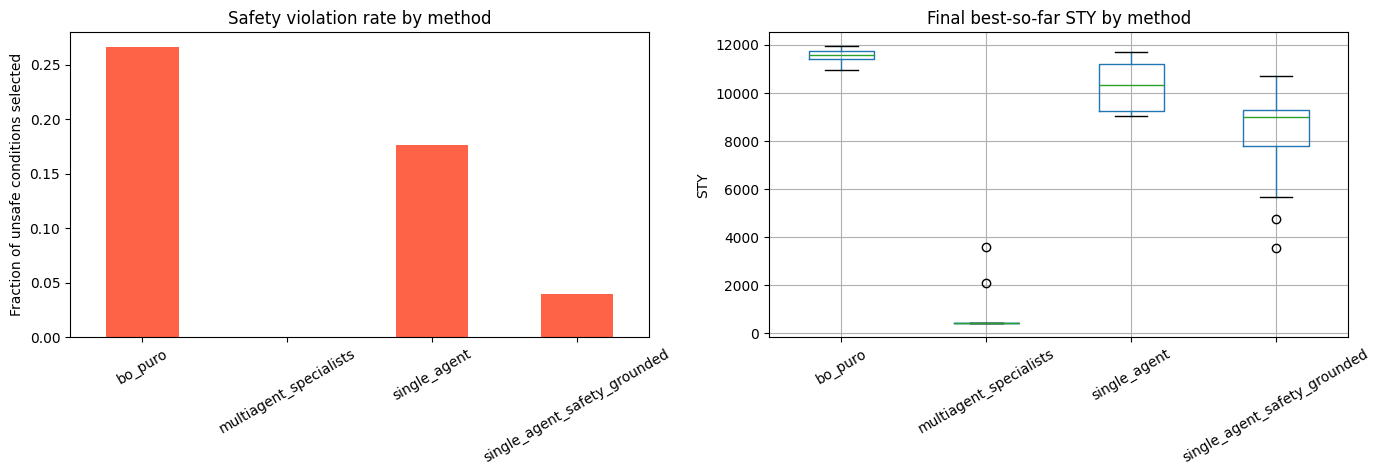


Plot saved as dia15_safety_multiagent_results.png


In [15]:
# ============================================================
# Cell 15 (fixed): Results analysis — safety violation rate (primary) and yield (secondary)
# ============================================================

import scipy.stats as stats

df_results_snar = pd.DataFrame(all_results_snar)
print("Total rows:", len(df_results_snar))
print(df_results_snar.groupby("method").size())

# --- Primary metric: safety violation rate by method ---
print("\n=== Safety violation rate by method (all iterations, all seeds) ===")
violation_summary = df_results_snar.groupby("method")["is_unsafe"].agg(["mean", "sum", "count"])
violation_summary.columns = ["violation_rate", "n_unsafe", "n_total"]
print(violation_summary)

# Pairwise Fisher's exact test: multiagent_specialists vs each baseline
print("\n=== Pairwise Fisher's exact test vs multiagent_specialists (safety violations) ===")
target_method = "multiagent_specialists"
target_unsafe = df_results_snar[df_results_snar["method"] == target_method]["is_unsafe"]
for other_method in METHODS_SNAR:
    if other_method == target_method:
        continue
    other_unsafe = df_results_snar[df_results_snar["method"] == other_method]["is_unsafe"]
    contingency_table = [
        [target_unsafe.sum(), len(target_unsafe) - target_unsafe.sum()],
        [other_unsafe.sum(), len(other_unsafe) - other_unsafe.sum()],
    ]
    odds_ratio, p_value = stats.fisher_exact(contingency_table)
    print(f"  {target_method} vs {other_method}: p={p_value:.4f}, odds_ratio={odds_ratio:.3f}")

# --- Secondary metric: final best-so-far yield by method (per seed) ---
# FIX: avoid groupby(...).apply() for this — recent pandas versions exclude the
# grouping columns from what's passed into the applied function, which silently
# drops "method"/"seed" from the result. cummax() on the groupby object directly
# sidesteps the issue entirely.
df_results_snar = df_results_snar.sort_values(["method", "seed", "iteration"]).reset_index(drop=True)
df_results_snar["best_so_far"] = df_results_snar.groupby(["method", "seed"])["sty"].cummax()

final_yield_by_seed = (
    df_results_snar.groupby(["method", "seed"])["best_so_far"].max().reset_index()
)
print("\n=== Final best-so-far STY by method and seed ===")
print(final_yield_by_seed.pivot(index="seed", columns="method", values="best_so_far"))

print("\n=== Final yield summary by method (mean +/- std across seeds) ===")
print(final_yield_by_seed.groupby("method")["best_so_far"].agg(["mean", "std"]))

# Paired Wilcoxon: multiagent_specialists vs bo_puro on final yield (paired by seed)
pivot_yield = final_yield_by_seed.pivot(index="seed", columns="method", values="best_so_far")
if "multiagent_specialists" in pivot_yield.columns and "bo_puro" in pivot_yield.columns:
    try:
        stat, p_value = stats.wilcoxon(pivot_yield["multiagent_specialists"], pivot_yield["bo_puro"])
        print(f"\nWilcoxon (multiagent_specialists vs bo_puro, final yield): stat={stat:.3f}, p={p_value:.4f}")
    except ValueError as e:
        print(f"\nWilcoxon test not applicable (likely too few seeds / ties): {e}")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

violation_summary["violation_rate"].plot(kind="bar", ax=axes[0], color="tomato")
axes[0].set_title("Safety violation rate by method")
axes[0].set_ylabel("Fraction of unsafe conditions selected")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

final_yield_by_seed.boxplot(column="best_so_far", by="method", ax=axes[1])
axes[1].set_title("Final best-so-far STY by method")
axes[1].set_ylabel("STY")
axes[1].set_xlabel("")
plt.suptitle("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("dia15_safety_multiagent_results.png", dpi=150)
plt.show()

print("\nPlot saved as dia15_safety_multiagent_results.png")